# Tugas 1 PCD - Down Sampling dan Up Sampling
Nama : Muhammad Gauza Faliha
Kelas : KOM A 
NIM : 25/555851/PA/23315
Prodi : Ilmu Komnputer

Dataset: Intel Image Classification (Kaggle)

In [1]:
!pip install kaggle -q


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install numpy matplotlib

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 1.3 MB/s eta 0:00:10
   -- ------------------------------------- 0.8/12.6 MB 1.2 MB/s eta 0:00:10
   --- ------------------------------------ 1.0/12.6 MB 1.2 MB/s eta 0:00:10
   ---- ----------------------------------- 1.3/12.6 MB 1.3 MB/s eta 0:00:09
   ----- ---------------------------------- 1.6/12.6 MB 1.2 MB/s eta 0:00:09
   ----- ---------------------------------- 1.6/12.6 MB 1.2 MB/s eta 0:00:09
   ----- ---------------------------------- 1.8/12.6 MB 1.1 MB/s eta 0:00:11
   ------ --------------------------------- 2.1/12.6 MB 1.0 MB/s eta 0:00:11
   ------- -------------------------------- 2.4/12.6 MB 1.1 MB/s eta 0:00:10
   -------- ------------------------------- 2.6/12.6 MB 1.1 MB/s eta 0:00:10
   --------- -------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"muhammadgauzafaliha","key":"0fee4afdac60d9de7b4bcbc2f7bcdc40"}')

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('token kaggle berhasil dibuat')

token kaggle berhasil dibuat


In [4]:
!kaggle datasets download -d puneet6060/intel-image-classification --unzip -p /content/dataset

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors




  0%|          | 0.00/346M [00:00<?, ?B/s]
  0%|          | 1.00M/346M [00:01<10:38, 567kB/s]
  1%|          | 2.00M/346M [00:02<06:26, 934kB/s]
  1%|          | 3.00M/346M [00:03<06:04, 987kB/s]
  1%|          | 4.00M/346M [00:04<05:08, 1.16MB/s]
  1%|▏         | 5.00M/346M [00:04<04:37, 1.29MB/s]
  2%|▏         | 6.00M/346M [00:05<04:32, 1.31MB/s]
  2%|▏         | 7.00M/346M [00:06<04:46, 1.24MB/s]
  2%|▏         | 8.00M/346M [00:07<05:10, 1.14MB/s]
  3%|▎         | 9.00M/346M [00:08<04:59, 1.18MB/s]
  3%|▎         | 10.0M/346M [00:09<04:53, 1.20MB/s]
  3%|▎         | 11.0M/346M [00:09<04:22, 1.34MB/s]
  3%|▎         | 12.0M/346M [00:10<04:08, 1.41MB/s]
  4%|▍         | 13.0M/346M [00:11<04:04, 1.43MB/s]
  4%|▍         | 14.0M/346M [00:12<04:35, 1.26MB/s]
  4%|▍         | 15.0M/346M [00:12<04:10, 1.38MB/s]
  5%|▍         | 16.0M/346M [00:13<03:43, 1.55MB/s]
  5%|▍         | 17.0M/346M [00:13<03:21, 1.71MB/s]
  5%|▌         | 18.0M/346M [00:14<03:05, 1.85MB/s]
  5%|▌         | 19.0M/

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Load Gambar dari Dataset

In [9]:
# ambil 50 gambar dari dataset
folder_dataset = '/content/dataset/seg_train/seg_train'

semua_gambar = []

for kategori in os.listdir(folder_dataset):
    folder_kat = os.path.join(folder_dataset, kategori)

    if os.path.isdir(folder_kat):
        for nama in os.listdir(folder_kat):
            if nama.endswith('.jpg'):
                semua_gambar.append((os.path.join(folder_kat, nama), kategori))

semua_gambar = semua_gambar[:50]

print('total gambar:', len(semua_gambar))

total gambar: 50


In [10]:
# load gambar dari 3 kategori: hutan, gedung, laut
folder_hutan = '/content/dataset/seg_train/seg_train/forest'
folder_gedung = '/content/dataset/seg_train/seg_train/buildings'
folder_laut = '/content/dataset/seg_train/seg_train/sea'

gambar_hutan = []
for nama in sorted(os.listdir(folder_hutan))[:3]:
    if nama.endswith('.jpg'):
        gambar_hutan.append((nama, mpimg.imread(os.path.join(folder_hutan, nama))))

gambar_gedung = []
for nama in sorted(os.listdir(folder_gedung))[:3]:
    if nama.endswith('.jpg'):
        gambar_gedung.append((nama, mpimg.imread(os.path.join(folder_gedung, nama))))

gambar_laut = []
for nama in sorted(os.listdir(folder_laut))[:3]:
    if nama.endswith('.jpg'):
        gambar_laut.append((nama, mpimg.imread(os.path.join(folder_laut, nama))))

print('gambar hutan:', len(gambar_hutan))
print('gambar gedung:', len(gambar_gedung))
print('gambar laut:', len(gambar_laut))

gambar hutan: 3
gambar gedung: 3
gambar laut: 3


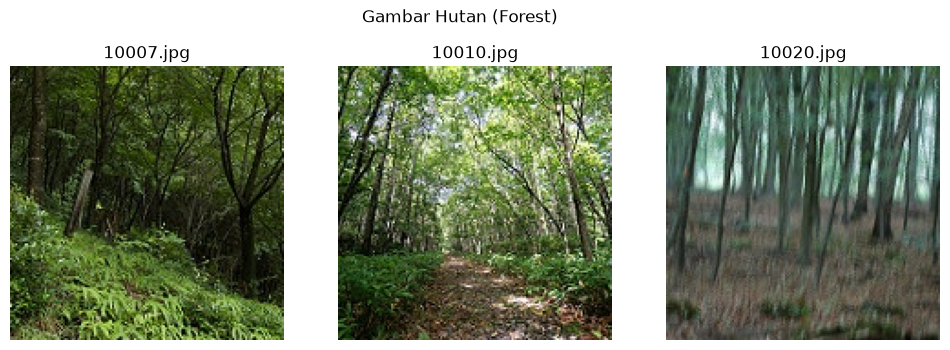

In [11]:
# tampilkan gambar hutan
plt.figure(figsize=(12, 4))

for i in range(len(gambar_hutan)):
    plt.subplot(1, len(gambar_hutan), i + 1)
    plt.imshow(gambar_hutan[i][1])
    plt.title(gambar_hutan[i][0])
    plt.axis('off')

plt.suptitle('Gambar Hutan (Forest)')
plt.show()

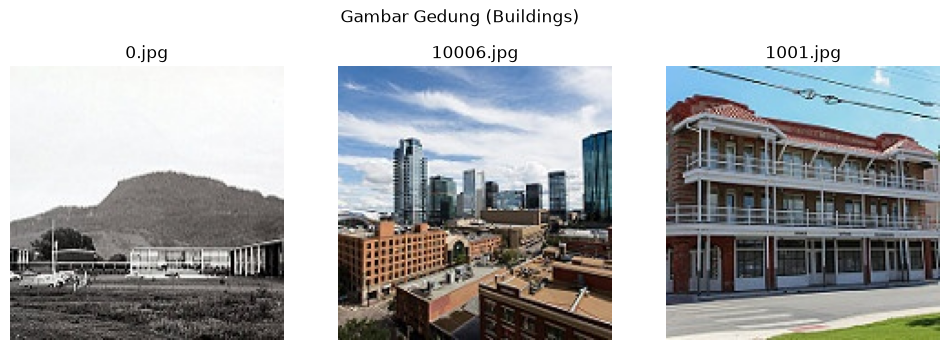

In [12]:
# tampilkan gambar gedung
plt.figure(figsize=(12, 4))

for i in range(len(gambar_gedung)):
    plt.subplot(1, len(gambar_gedung), i + 1)
    plt.imshow(gambar_gedung[i][1])
    plt.title(gambar_gedung[i][0])
    plt.axis('off')

plt.suptitle('Gambar Gedung (Buildings)')
plt.show()

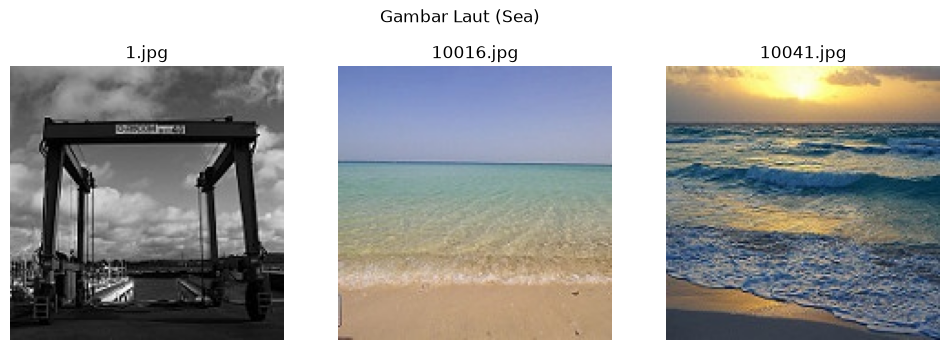

In [13]:
# tampilkan gambar laut
plt.figure(figsize=(12, 4))

for i in range(len(gambar_laut)):
    plt.subplot(1, len(gambar_laut), i + 1)
    plt.imshow(gambar_laut[i][1])
    plt.title(gambar_laut[i][0])
    plt.axis('off')

plt.suptitle('Gambar Laut (Sea)')
plt.show()

## Pilih Gambar untuk Analisis

In [14]:
# ambil 1 gambar dari tiap kategori
gambar1 = gambar_hutan[0][1]
gambar2 = gambar_gedung[0][1]
gambar3 = gambar_laut[0][1]

print('gambar hutan:', gambar1.shape[0], 'x', gambar1.shape[1], '- pixel:', gambar1.shape[0] * gambar1.shape[1])
print('gambar gedung:', gambar2.shape[0], 'x', gambar2.shape[1], '- pixel:', gambar2.shape[0] * gambar2.shape[1])
print('gambar laut:', gambar3.shape[0], 'x', gambar3.shape[1], '- pixel:', gambar3.shape[0] * gambar3.shape[1])

gambar hutan: 150 x 150 - pixel: 22500
gambar gedung: 150 x 150 - pixel: 22500
gambar laut: 150 x 150 - pixel: 22500


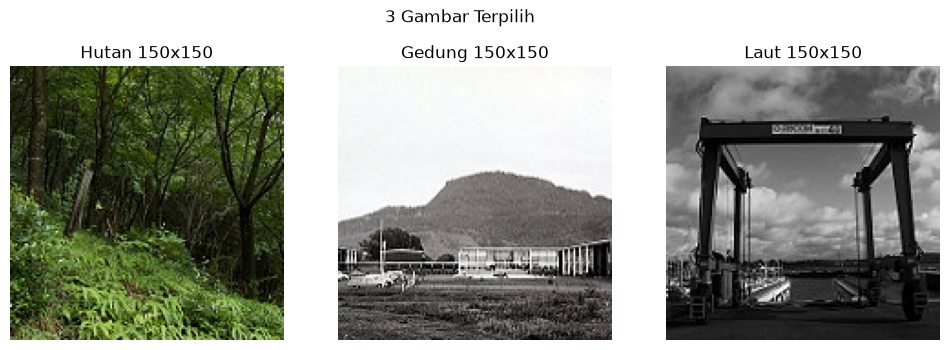

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gambar1)
plt.title('Hutan ' + str(gambar1.shape[0]) + 'x' + str(gambar1.shape[1]))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gambar2)
plt.title('Gedung ' + str(gambar2.shape[0]) + 'x' + str(gambar2.shape[1]))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gambar3)
plt.title('Laut ' + str(gambar3.shape[0]) + 'x' + str(gambar3.shape[1]))
plt.axis('off')

plt.suptitle('3 Gambar Terpilih')
plt.show()



## Down Sampling

Mengurangi resolusi gambar dengan faktor 2 (ukuran jadi setengah).
Pakai gambar hutan sebagai contoh utama.

### Max Down Sampling

In [16]:
def max_downsampling(gambar, faktor):

    tinggi = gambar.shape[0]
    lebar = gambar.shape[1]
    kanal = gambar.shape[2]

    tinggi_baru = tinggi // faktor
    lebar_baru = lebar // faktor

    hasil = np.zeros((tinggi_baru, lebar_baru, kanal), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):

            blok = gambar[i * faktor : (i + 1) * faktor,
                          j * faktor : (j + 1) * faktor]

            for c in range(kanal):
                nilai_max = blok[0, 0, c]

                for bi in range(faktor):
                    for bj in range(faktor):
                        if blok[bi, bj, c] > nilai_max:
                            nilai_max = blok[bi, bj, c]

                hasil[i, j, c] = nilai_max

    return hasil

sebelum: 150 x 150 - pixel: 22500
sesudah: 75 x 75 - pixel: 5625


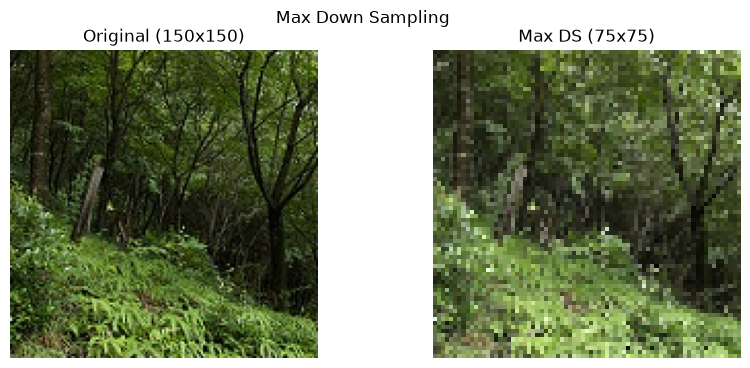

In [17]:
# jalankan max downsampling
hasil_max = max_downsampling(gambar1, 2)

print('sebelum:', gambar1.shape[0], 'x', gambar1.shape[1], '- pixel:', gambar1.shape[0] * gambar1.shape[1])
print('sesudah:', hasil_max.shape[0], 'x', hasil_max.shape[1], '- pixel:', hasil_max.shape[0] * hasil_max.shape[1])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gambar1)
plt.title('Original (' + str(gambar1.shape[0]) + 'x' + str(gambar1.shape[1]) + ')')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_max)
plt.title('Max DS (' + str(hasil_max.shape[0]) + 'x' + str(hasil_max.shape[1]) + ')')
plt.axis('off')

plt.suptitle('Max Down Sampling')
plt.show()

### Average Down Sampling

In [18]:
def average_downsampling(gambar, faktor):

    tinggi = gambar.shape[0]
    lebar = gambar.shape[1]
    kanal = gambar.shape[2]

    tinggi_baru = tinggi // faktor
    lebar_baru = lebar // faktor

    hasil = np.zeros((tinggi_baru, lebar_baru, kanal), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):

            blok = gambar[i * faktor : (i + 1) * faktor,
                          j * faktor : (j + 1) * faktor]

            for c in range(kanal):
                total = 0.0
                jumlah = 0

                for bi in range(faktor):
                    for bj in range(faktor):
                        total = total + float(blok[bi, bj, c])
                        jumlah = jumlah + 1

                hasil[i, j, c] = int(total / jumlah)

    return hasil

sebelum: 150 x 150 - pixel: 22500
sesudah: 75 x 75 - pixel: 5625


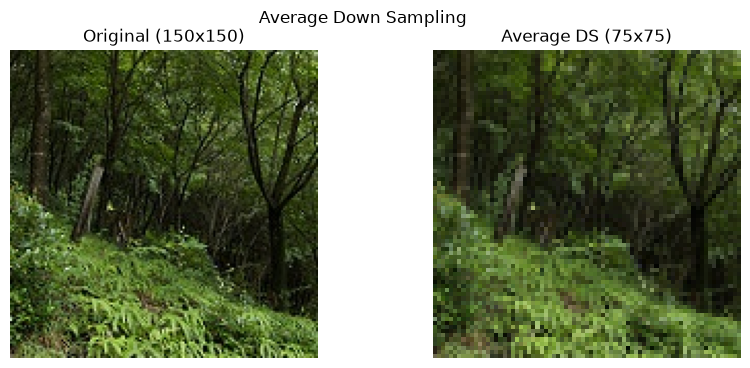

In [19]:
# jalankan average downsampling
hasil_avg = average_downsampling(gambar1, 2)

print('sebelum:', gambar1.shape[0], 'x', gambar1.shape[1], '- pixel:', gambar1.shape[0] * gambar1.shape[1])
print('sesudah:', hasil_avg.shape[0], 'x', hasil_avg.shape[1], '- pixel:', hasil_avg.shape[0] * hasil_avg.shape[1])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gambar1)
plt.title('Original (' + str(gambar1.shape[0]) + 'x' + str(gambar1.shape[1]) + ')')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_avg)
plt.title('Average DS (' + str(hasil_avg.shape[0]) + 'x' + str(hasil_avg.shape[1]) + ')')
plt.axis('off')

plt.suptitle('Average Down Sampling')
plt.show()

### Median Down Sampling

In [20]:
def median_downsampling(gambar, faktor):

    tinggi = gambar.shape[0]
    lebar = gambar.shape[1]
    kanal = gambar.shape[2]

    tinggi_baru = tinggi // faktor
    lebar_baru = lebar // faktor

    hasil = np.zeros((tinggi_baru, lebar_baru, kanal), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):

            blok = gambar[i * faktor : (i + 1) * faktor,
                          j * faktor : (j + 1) * faktor]

            for c in range(kanal):
                # kumpulin semua nilai
                nilai = []
                for bi in range(faktor):
                    for bj in range(faktor):
                        nilai.append(int(blok[bi, bj, c]))

                # urutkan pakai bubble sort
                for p in range(len(nilai)):
                    for q in range(len(nilai) - p - 1):
                        if nilai[q] > nilai[q + 1]:
                            nilai[q], nilai[q + 1] = nilai[q + 1], nilai[q]

                # ambil yang tengah
                hasil[i, j, c] = nilai[len(nilai) // 2]

    return hasil

sebelum: 150 x 150 - pixel: 22500
sesudah: 75 x 75 - pixel: 5625


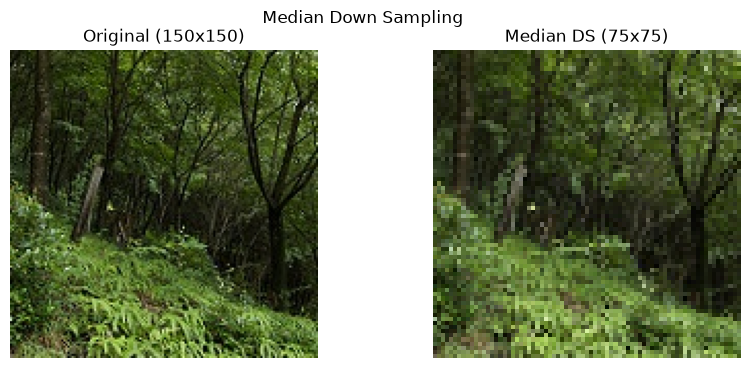

In [21]:
# jalankan median downsampling
hasil_med = median_downsampling(gambar1, 2)

print('sebelum:', gambar1.shape[0], 'x', gambar1.shape[1], '- pixel:', gambar1.shape[0] * gambar1.shape[1])
print('sesudah:', hasil_med.shape[0], 'x', hasil_med.shape[1], '- pixel:', hasil_med.shape[0] * hasil_med.shape[1])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gambar1)
plt.title('Original (' + str(gambar1.shape[0]) + 'x' + str(gambar1.shape[1]) + ')')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_med)
plt.title('Median DS (' + str(hasil_med.shape[0]) + 'x' + str(hasil_med.shape[1]) + ')')
plt.axis('off')

plt.suptitle('Median Down Sampling')
plt.show()

### Perbandingan Down Sampling

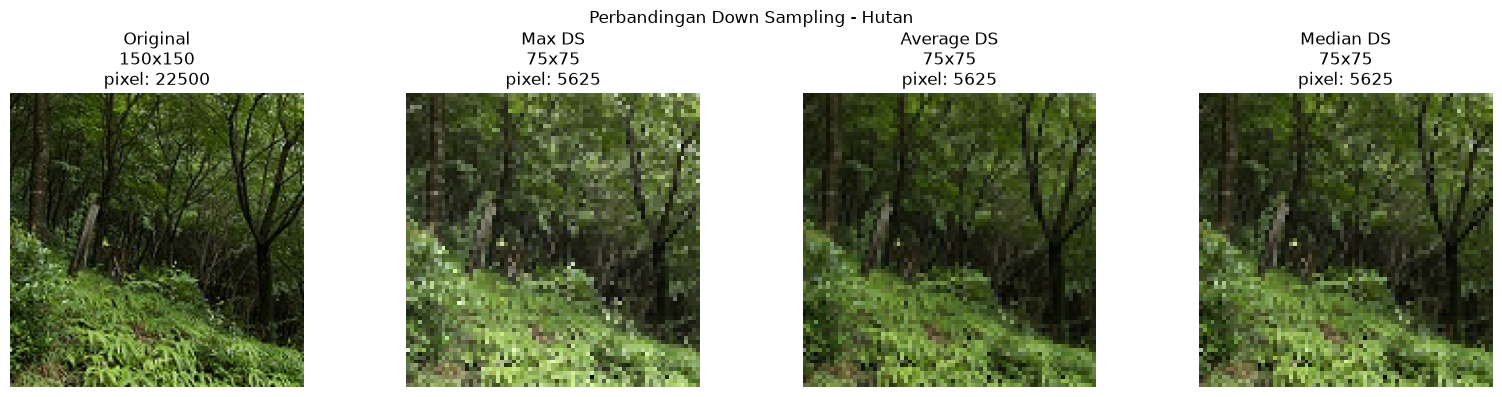

In [22]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(gambar1)
plt.title('Original\n' + str(gambar1.shape[0]) + 'x' + str(gambar1.shape[1]) + '\npixel: ' + str(gambar1.shape[0] * gambar1.shape[1]))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(hasil_max)
plt.title('Max DS\n' + str(hasil_max.shape[0]) + 'x' + str(hasil_max.shape[1]) + '\npixel: ' + str(hasil_max.shape[0] * hasil_max.shape[1]))
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(hasil_avg)
plt.title('Average DS\n' + str(hasil_avg.shape[0]) + 'x' + str(hasil_avg.shape[1]) + '\npixel: ' + str(hasil_avg.shape[0] * hasil_avg.shape[1]))
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(hasil_med)
plt.title('Median DS\n' + str(hasil_med.shape[0]) + 'x' + str(hasil_med.shape[1]) + '\npixel: ' + str(hasil_med.shape[0] * hasil_med.shape[1]))
plt.axis('off')

plt.suptitle('Perbandingan Down Sampling - Hutan')
plt.tight_layout()
plt.show()



## Up Sampling

Memperbesar gambar yang sudah di-downsample balik ke ukuran asli.
Pakai hasil average down sampling sebagai input.

gambar kecil: 75 x 75
target: 150 x 150


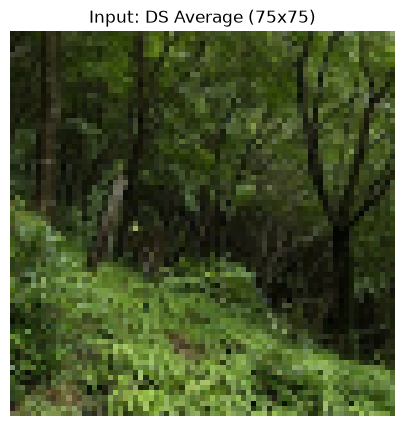

In [23]:
# gambar yang akan di-upsample
gambar_kecil = hasil_avg

tinggi_asli = gambar1.shape[0]
lebar_asli = gambar1.shape[1]

print('gambar kecil:', gambar_kecil.shape[0], 'x', gambar_kecil.shape[1])
print('target:', tinggi_asli, 'x', lebar_asli)

plt.figure(figsize=(5, 5))
plt.imshow(gambar_kecil)
plt.title('Input: DS Average (' + str(gambar_kecil.shape[0]) + 'x' + str(gambar_kecil.shape[1]) + ')')
plt.axis('off')
plt.show()

### Nearest Neighbor Up Sampling

In [24]:
def nn_upsampling(gambar, tinggi_target, lebar_target):

    tinggi = gambar.shape[0]
    lebar = gambar.shape[1]
    kanal = gambar.shape[2]

    hasil = np.zeros((tinggi_target, lebar_target, kanal), dtype=np.uint8)

    rasio_y = tinggi / tinggi_target
    rasio_x = lebar / lebar_target

    for i in range(tinggi_target):
        for j in range(lebar_target):

            # cari piksel terdekat
            y = int(i * rasio_y)
            x = int(j * rasio_x)

            if y >= tinggi:
                y = tinggi - 1
            if x >= lebar:
                x = lebar - 1

            hasil[i, j] = gambar[y, x]

    return hasil

sebelum: 75 x 75 - pixel: 5625
sesudah: 150 x 150 - pixel: 22500


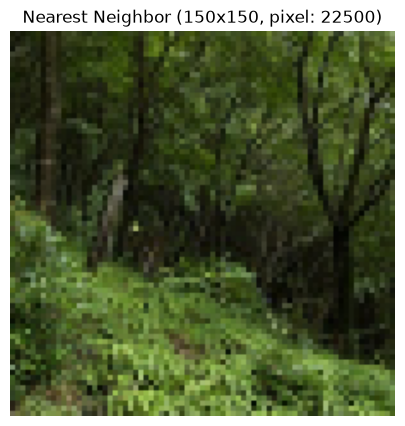

In [25]:
# jalankan nearest neighbor
hasil_nn = nn_upsampling(gambar_kecil, tinggi_asli, lebar_asli)

print('sebelum:', gambar_kecil.shape[0], 'x', gambar_kecil.shape[1], '- pixel:', gambar_kecil.shape[0] * gambar_kecil.shape[1])
print('sesudah:', hasil_nn.shape[0], 'x', hasil_nn.shape[1], '- pixel:', hasil_nn.shape[0] * hasil_nn.shape[1])

plt.figure(figsize=(5, 5))
plt.imshow(hasil_nn)
plt.title('Nearest Neighbor (' + str(hasil_nn.shape[0]) + 'x' + str(hasil_nn.shape[1]) + ', pixel: ' + str(hasil_nn.shape[0] * hasil_nn.shape[1]) + ')')
plt.axis('off')
plt.show()

### Bilinear Up Sampling

In [26]:
def bilinear_upsampling(gambar, tinggi_target, lebar_target):

    tinggi = gambar.shape[0]
    lebar = gambar.shape[1]
    kanal = gambar.shape[2]

    hasil = np.zeros((tinggi_target, lebar_target, kanal), dtype=np.uint8)

    rasio_y = (tinggi - 1) / (tinggi_target - 1)
    rasio_x = (lebar - 1) / (lebar_target - 1)

    for i in range(tinggi_target):
        for j in range(lebar_target):

            y = i * rasio_y
            x = j * rasio_x

            # 4 tetangga terdekat
            y0 = int(y)
            x0 = int(x)
            y1 = min(y0 + 1, tinggi - 1)
            x1 = min(x0 + 1, lebar - 1)

            dy = y - y0
            dx = x - x0

            for c in range(kanal):

                atas_kiri = float(gambar[y0, x0, c])
                atas_kanan = float(gambar[y0, x1, c])
                bawah_kiri = float(gambar[y1, x0, c])
                bawah_kanan = float(gambar[y1, x1, c])

                nilai = (1 - dx) * (1 - dy) * atas_kiri + dx * (1 - dy) * atas_kanan + (1 - dx) * dy * bawah_kiri + dx * dy * bawah_kanan

                if nilai < 0:
                    nilai = 0
                if nilai > 255:
                    nilai = 255

                hasil[i, j, c] = int(nilai)

    return hasil

sebelum: 75 x 75 - pixel: 5625
sesudah: 150 x 150 - pixel: 22500


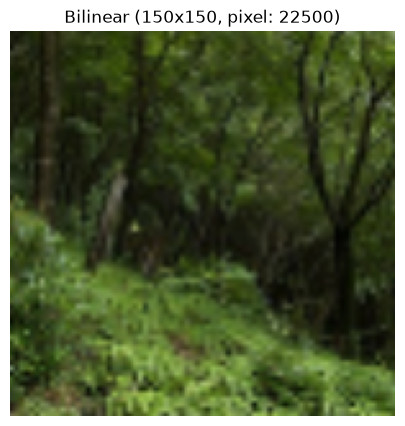

In [27]:
# jalankan bilinear
hasil_bilinear = bilinear_upsampling(gambar_kecil, tinggi_asli, lebar_asli)

print('sebelum:', gambar_kecil.shape[0], 'x', gambar_kecil.shape[1], '- pixel:', gambar_kecil.shape[0] * gambar_kecil.shape[1])
print('sesudah:', hasil_bilinear.shape[0], 'x', hasil_bilinear.shape[1], '- pixel:', hasil_bilinear.shape[0] * hasil_bilinear.shape[1])

plt.figure(figsize=(5, 5))
plt.imshow(hasil_bilinear)
plt.title('Bilinear (' + str(hasil_bilinear.shape[0]) + 'x' + str(hasil_bilinear.shape[1]) + ', pixel: ' + str(hasil_bilinear.shape[0] * hasil_bilinear.shape[1]) + ')')
plt.axis('off')
plt.show()

### Bicubic Up Sampling

In [28]:
# fungsi kernel kubik buat bicubic
def kernel_kubik(t):

    a = -0.5
    t = abs(t)

    if t <= 1:
        return (a + 2) * t * t * t - (a + 3) * t * t + 1
    elif t < 2:
        return a * t * t * t - 5 * a * t * t + 8 * a * t - 4 * a
    else:
        return 0.0


def bicubic_upsampling(gambar, tinggi_target, lebar_target):

    tinggi = gambar.shape[0]
    lebar = gambar.shape[1]
    kanal = gambar.shape[2]

    hasil = np.zeros((tinggi_target, lebar_target, kanal), dtype=np.uint8)

    rasio_y = (tinggi - 1) / (tinggi_target - 1)
    rasio_x = (lebar - 1) / (lebar_target - 1)

    for i in range(tinggi_target):
        for j in range(lebar_target):

            y = i * rasio_y
            x = j * rasio_x

            y0 = int(y)
            x0 = int(x)
            dy = y - y0
            dx = x - x0

            for c in range(kanal):
                nilai = 0.0

                # pakai 16 tetangga (4x4)
                for m in range(-1, 3):
                    for n in range(-1, 3):

                        yi = y0 + m
                        xi = x0 + n

                        # batasin biar ga keluar
                        if yi < 0:
                            yi = 0
                        if yi >= tinggi:
                            yi = tinggi - 1
                        if xi < 0:
                            xi = 0
                        if xi >= lebar:
                            xi = lebar - 1

                        bobot = kernel_kubik(m - dy) * kernel_kubik(n - dx)
                        nilai = nilai + float(gambar[yi, xi, c]) * bobot

                if nilai < 0:
                    nilai = 0
                if nilai > 255:
                    nilai = 255

                hasil[i, j, c] = int(nilai)

    return hasil

proses bicubic...
selesai
sebelum: 75 x 75 - pixel: 5625
sesudah: 150 x 150 - pixel: 22500


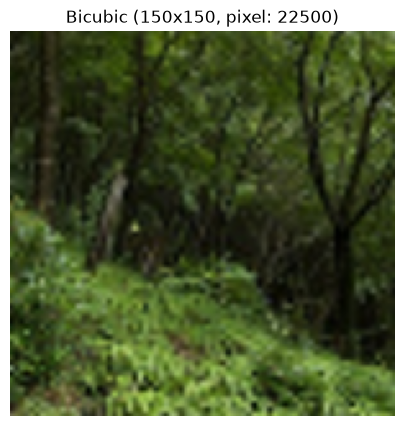

In [29]:
# jalankan bicubic (agak lama prosesnya)
print('proses bicubic...')

hasil_bicubic = bicubic_upsampling(gambar_kecil, tinggi_asli, lebar_asli)

print('selesai')
print('sebelum:', gambar_kecil.shape[0], 'x', gambar_kecil.shape[1], '- pixel:', gambar_kecil.shape[0] * gambar_kecil.shape[1])
print('sesudah:', hasil_bicubic.shape[0], 'x', hasil_bicubic.shape[1], '- pixel:', hasil_bicubic.shape[0] * hasil_bicubic.shape[1])

plt.figure(figsize=(5, 5))
plt.imshow(hasil_bicubic)
plt.title('Bicubic (' + str(hasil_bicubic.shape[0]) + 'x' + str(hasil_bicubic.shape[1]) + ', pixel: ' + str(hasil_bicubic.shape[0] * hasil_bicubic.shape[1]) + ')')
plt.axis('off')
plt.show()

### Perbandingan Up Sampling

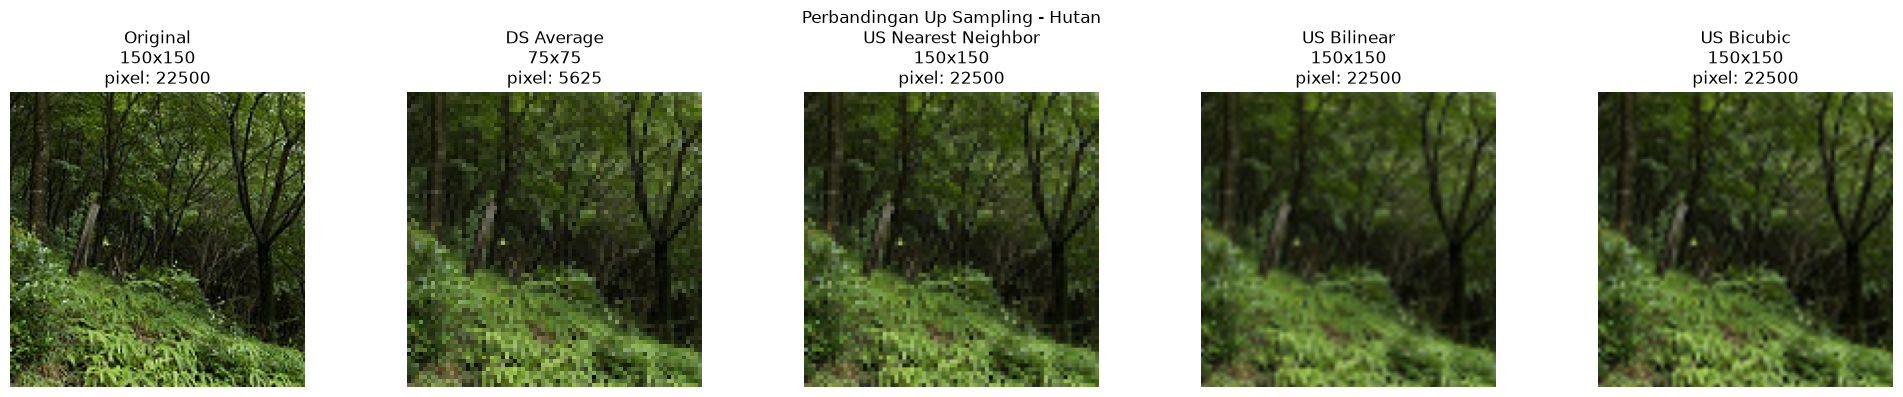

In [30]:
plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.imshow(gambar1)
plt.title('Original\n' + str(gambar1.shape[0]) + 'x' + str(gambar1.shape[1]) + '\npixel: ' + str(gambar1.shape[0] * gambar1.shape[1]))
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(gambar_kecil)
plt.title('DS Average\n' + str(gambar_kecil.shape[0]) + 'x' + str(gambar_kecil.shape[1]) + '\npixel: ' + str(gambar_kecil.shape[0] * gambar_kecil.shape[1]))
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(hasil_nn)
plt.title('US Nearest Neighbor\n' + str(hasil_nn.shape[0]) + 'x' + str(hasil_nn.shape[1]) + '\npixel: ' + str(hasil_nn.shape[0] * hasil_nn.shape[1]))
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(hasil_bilinear)
plt.title('US Bilinear\n' + str(hasil_bilinear.shape[0]) + 'x' + str(hasil_bilinear.shape[1]) + '\npixel: ' + str(hasil_bilinear.shape[0] * hasil_bilinear.shape[1]))
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(hasil_bicubic)
plt.title('US Bicubic\n' + str(hasil_bicubic.shape[0]) + 'x' + str(hasil_bicubic.shape[1]) + '\npixel: ' + str(hasil_bicubic.shape[0] * hasil_bicubic.shape[1]))
plt.axis('off')

plt.suptitle('Perbandingan Up Sampling - Hutan')
plt.tight_layout()
plt.show()


## Proses untuk Gambar Gedung

original: 150 x 150 - pixel: 22500
setelah DS: 75 x 75 - pixel: 5625


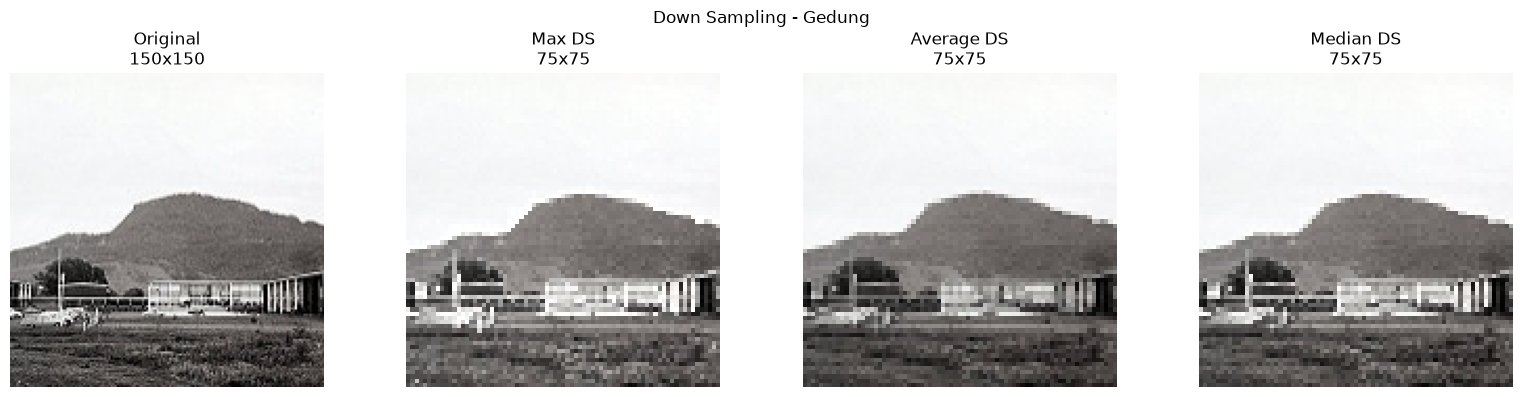

In [31]:
# down sampling gambar gedung
ds_max_gedung = max_downsampling(gambar2, 2)
ds_avg_gedung = average_downsampling(gambar2, 2)
ds_med_gedung = median_downsampling(gambar2, 2)

print('original:', gambar2.shape[0], 'x', gambar2.shape[1], '- pixel:', gambar2.shape[0] * gambar2.shape[1])
print('setelah DS:', ds_avg_gedung.shape[0], 'x', ds_avg_gedung.shape[1], '- pixel:', ds_avg_gedung.shape[0] * ds_avg_gedung.shape[1])

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(gambar2)
plt.title('Original\n' + str(gambar2.shape[0]) + 'x' + str(gambar2.shape[1]))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(ds_max_gedung)
plt.title('Max DS\n' + str(ds_max_gedung.shape[0]) + 'x' + str(ds_max_gedung.shape[1]))
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(ds_avg_gedung)
plt.title('Average DS\n' + str(ds_avg_gedung.shape[0]) + 'x' + str(ds_avg_gedung.shape[1]))
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(ds_med_gedung)
plt.title('Median DS\n' + str(ds_med_gedung.shape[0]) + 'x' + str(ds_med_gedung.shape[1]))
plt.axis('off')

plt.suptitle('Down Sampling - Gedung')
plt.tight_layout()
plt.show()

proses up sampling gedung...
selesai


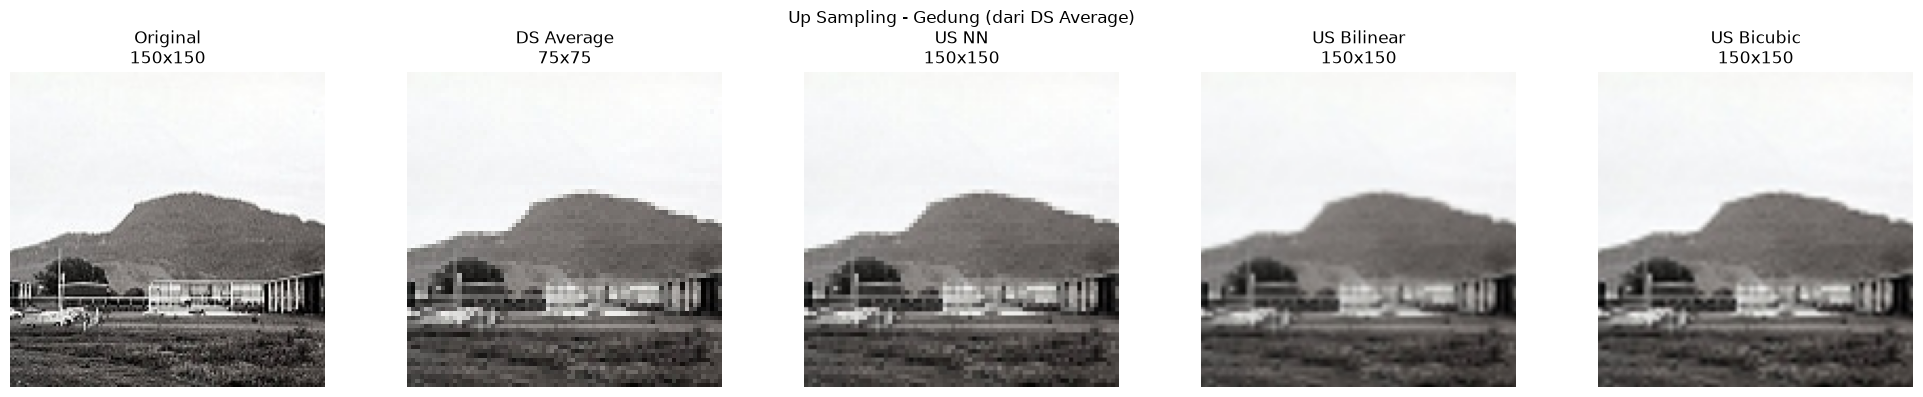

In [32]:
# up sampling gambar gedung dari ds average
print('proses up sampling gedung...')

us_nn_gedung = nn_upsampling(ds_avg_gedung, gambar2.shape[0], gambar2.shape[1])
us_bil_gedung = bilinear_upsampling(ds_avg_gedung, gambar2.shape[0], gambar2.shape[1])
us_bic_gedung = bicubic_upsampling(ds_avg_gedung, gambar2.shape[0], gambar2.shape[1])

print('selesai')

plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.imshow(gambar2)
plt.title('Original\n' + str(gambar2.shape[0]) + 'x' + str(gambar2.shape[1]))
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(ds_avg_gedung)
plt.title('DS Average\n' + str(ds_avg_gedung.shape[0]) + 'x' + str(ds_avg_gedung.shape[1]))
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(us_nn_gedung)
plt.title('US NN\n' + str(us_nn_gedung.shape[0]) + 'x' + str(us_nn_gedung.shape[1]))
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(us_bil_gedung)
plt.title('US Bilinear\n' + str(us_bil_gedung.shape[0]) + 'x' + str(us_bil_gedung.shape[1]))
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(us_bic_gedung)
plt.title('US Bicubic\n' + str(us_bic_gedung.shape[0]) + 'x' + str(us_bic_gedung.shape[1]))
plt.axis('off')

plt.suptitle('Up Sampling - Gedung (dari DS Average)')
plt.tight_layout()
plt.show()



## Proses untuk Gambar Laut

File laut yang diproses: 1.jpg
original: 150 x 150 - pixel: 22500
setelah DS: 75 x 75 - pixel: 5625


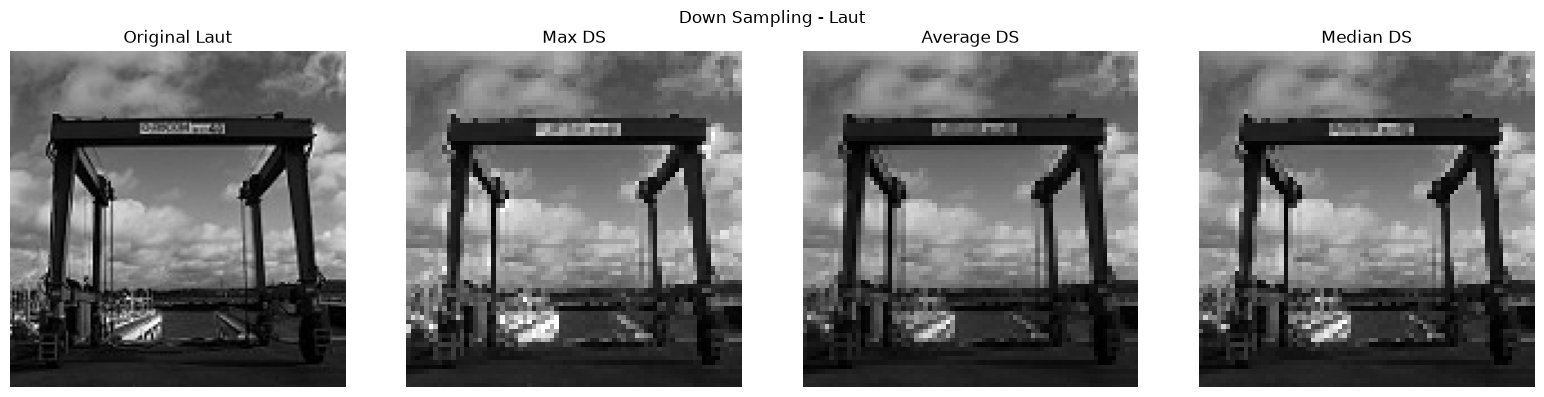

In [41]:
# Pastikan gambar yang dipakai benar-benar dari kategori laut
path_laut = gambar_laut[0][0]
gambar_laut_pilih = gambar_laut[0][1]

print('File laut yang diproses:', os.path.basename(path_laut))

# Down sampling gambar laut
ds_max_laut = max_downsampling(gambar_laut_pilih, 2)
ds_avg_laut = average_downsampling(gambar_laut_pilih, 2)
ds_med_laut = median_downsampling(gambar_laut_pilih, 2)

print('original:', gambar_laut_pilih.shape[0], 'x', gambar_laut_pilih.shape[1],
      '- pixel:', gambar_laut_pilih.shape[0] * gambar_laut_pilih.shape[1])

print('setelah DS:', ds_avg_laut.shape[0], 'x', ds_avg_laut.shape[1],
      '- pixel:', ds_avg_laut.shape[0] * ds_avg_laut.shape[1])

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(gambar_laut_pilih)
plt.title('Original Laut')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(ds_max_laut)
plt.title('Max DS')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(ds_avg_laut)
plt.title('Average DS')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(ds_med_laut)
plt.title('Median DS')
plt.axis('off')

plt.suptitle('Down Sampling - Laut')
plt.tight_layout()
plt.show()

proses up sampling laut...
selesai


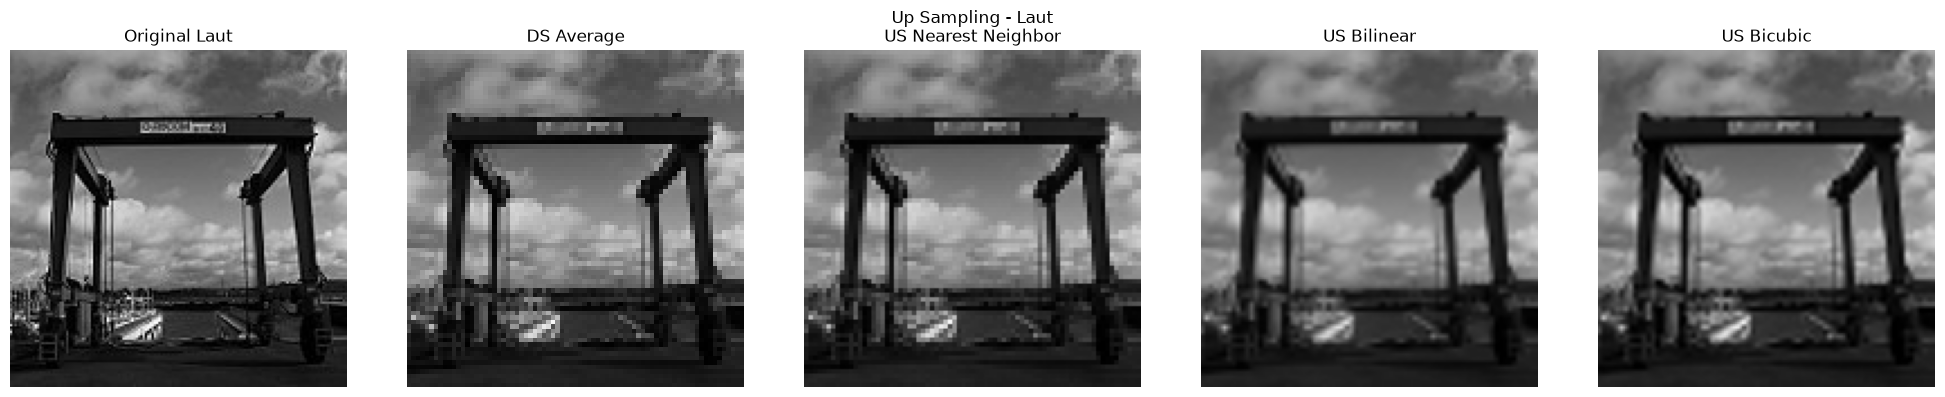

In [42]:
# Up sampling gambar laut dari hasil Average Down Sampling
print('proses up sampling laut...')

tinggi_laut = gambar_laut_pilih.shape[0]
lebar_laut = gambar_laut_pilih.shape[1]

us_nn_laut = nn_upsampling(ds_avg_laut, tinggi_laut, lebar_laut)
us_bil_laut = bilinear_upsampling(ds_avg_laut, tinggi_laut, lebar_laut)
us_bic_laut = bicubic_upsampling(ds_avg_laut, tinggi_laut, lebar_laut)

print('selesai')

plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.imshow(gambar_laut_pilih)
plt.title('Original Laut')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(ds_avg_laut)
plt.title('DS Average')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(us_nn_laut)
plt.title('US Nearest Neighbor')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(us_bil_laut)
plt.title('US Bilinear')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(us_bic_laut)
plt.title('US Bicubic')
plt.axis('off')

plt.suptitle('Up Sampling - Laut')
plt.tight_layout()
plt.show()



## 50 Gambar dari Dataset

Total gambar: 50


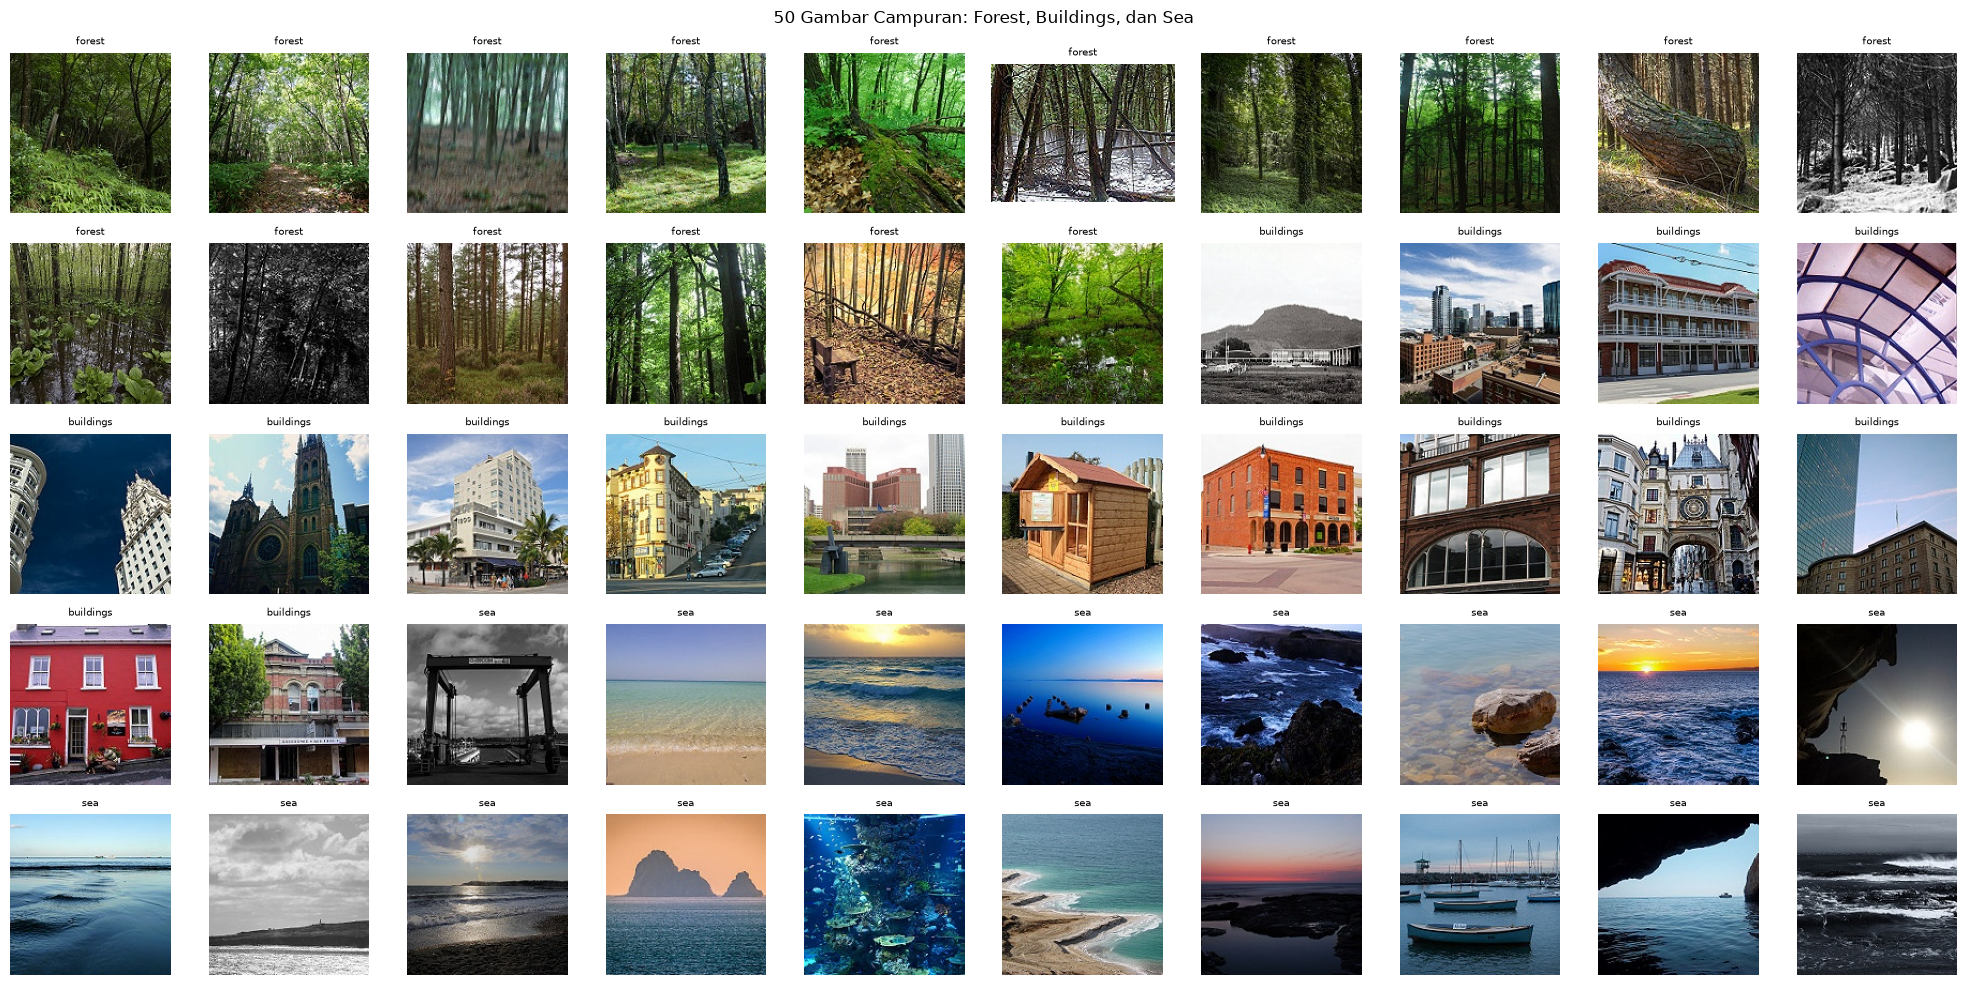

In [40]:
kategori_pilihan = ['forest', 'buildings', 'sea']
jumlah_per_kategori = 16

semua_gambar = []

for kategori in kategori_pilihan:
    folder_kategori = os.path.join(folder_dataset, kategori)

    daftar_file = [
        nama for nama in sorted(os.listdir(folder_kategori))
        if nama.lower().endswith('.jpg')
    ]

    for nama in daftar_file[:jumlah_per_kategori]:
        path = os.path.join(folder_kategori, nama)
        semua_gambar.append((path, kategori))

# Tambahkan 2 gambar supaya total menjadi 50
for nama in daftar_file[16:18]:
    path = os.path.join(folder_laut, nama)
    semua_gambar.append((path, 'sea'))

print('Total gambar:', len(semua_gambar))

fig, ax = plt.subplots(5, 10, figsize=(20, 10))

for idx, (path, kategori) in enumerate(semua_gambar):
    baris = idx // 10
    kolom = idx % 10

    img = mpimg.imread(path)
    ax[baris, kolom].imshow(img)
    ax[baris, kolom].set_title(kategori, fontsize=7)
    ax[baris, kolom].axis('off')

plt.suptitle('50 Gambar Campuran: Forest, Buildings, dan Sea')
plt.tight_layout()
plt.show()